In [107]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
load_dotenv()
from langchain_groq import ChatGroq
import operator
from typing import TypedDict, Annotated


In [108]:
model = ChatGroq(model="llama-3.1-8b-instant")

In [109]:
from pydantic import BaseModel, Field

class EvaluationSchema(BaseModel):
    score: str= Field(description='rate the essay uot of 10')
    feedback: str= Field(description='provide a natural frrdback based on the essay')
    

In [110]:
structured_model= model.with_structured_output(EvaluationSchema)

In [111]:
essay= """Artificial Intelligence (AI) is transforming the world, and India is emerging as an important player in this field. With a large pool of skilled engineers, a rapidly growing technology sector, and strong government support, India is making significant contributions to AI research and innovation.

The Indian government has launched several initiatives to promote AI in areas such as healthcare, education, agriculture, and smart cities. Programs like Digital India and the National AI Strategy encourage the development and adoption of AI technologies to improve public services and economic growth.

India is also home to many startups and technology companies that use AI to solve real-world problems. These organizations are developing intelligent solutions for language translation, financial services, medical diagnosis, and customer support. Additionally, Indian universities and research institutions are producing talented professionals who contribute to global AI advancements.

Despite its progress"""

In [112]:
# prompt = f"The essay is on Rise  of ai {essay}, now give feedback"
# resp = structured_model.invoke(prompt)
# print(resp)

In [113]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    indivisual_feedback: float
    avg_score: float

    indivisual_scores: Annotated[list[int], operator.add] 

In [114]:
def eval_language(state: UPSCState):
    prompt=f"evaluate its language of the folowing {state['essay']}"
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'indivisual_scores':[output.score]}

In [115]:
def eval_analysis(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of following and provide a feedback out of 10 {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'indivisual_scores': [int(output.score)]}


In [116]:
def eval_thought(state: UPSCState):

    prompt = f'Evaluate the depth of analysis of following and provide a feedback out of 10 {state['essay']}'
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'indivisual_scores': [int(output.score)]}
    

In [123]:
def final_evaluation(state:UPSCState):
    prompt = f"Give a final evaluation according to {state['language_feedback']}  /n analysis feedback {state['analysis_feedback']}/n clarity feedback {state['clarity_feedback']}"
    final_feedback = model.invoke(prompt).content

    avg_score = sum(state["indivisual_scores"])/len(state["indivisual_scores"])
    return {"overall_feedback": final_feedback, "avg_score": (avg_score)}

In [124]:
graph = StateGraph(UPSCState)

graph.add_node("evaluate_lang", eval_language)
graph.add_node("evaluate_anal", eval_analysis)
graph.add_node("evaluate_thoug", eval_thought)
graph.add_node('final_eval', final_evaluation)

In [125]:
graph.add_edge(START, "evaluate_lang")
graph.add_edge(START, "evaluate_anal")
graph.add_edge(START, "evaluate_thoug")
graph.add_edge("evaluate_lang", "final_eval")
graph.add_edge("evaluate_anal", "final_eval")
graph.add_edge("evaluate_thoug", "final_eval")
graph.add_edge("final_eval", END)

workflow = graph.compile()

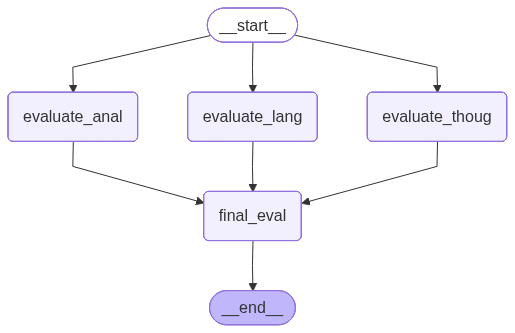

In [126]:
workflow

In [127]:
initial_state = {"essay": essay}

final_state = workflow.invoke(initial_state)
print(final_state)

BadRequestError: Error code: 400 - {'error': {'message': "tool call validation failed: parameters for tool EvaluationSchema did not match schema: errors: [missing properties: 'score']", 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=EvaluationSchema> {"feedback": "The essay provides a good overview of India\'s growth in the field of Artificial Intelligence, but lacks depth in critical analysis. The writer presents various initiatives and contributions, but fails to evaluate their effectiveness and provide concrete examples. Score: 8/10"} </function>'}}